# Using ROCS Scorer in DrugEx RNN - Memory Optimized

How to integrate the ROCS scorer into a DrugEx RNN workflow with OOM prevention

- Configuring memory-optimized ROCS scorers (Smart CLI ROCS recommended)
- Scoring and visualizing example SMILES  
- Building a multi‑objective environment combining ROCS similarity and synthetic‑accessibility  
- Fine‑tuning and reinforcement‑learning of an RNN generator with memory management
- Evaluating generated molecules with optimized batch sizes

## Prerequisites

To run this notebook, you need:
1. The DrugEx package installed
2. OpenEye toolkit with a valid license  
3. A ROCS query file (.sq format)
4. **Sufficient system memory** (16GB+ recommended for larger datasets)

## 1. Setting Up ROCS Scorer



In [2]:
from drugex.training.scorers.ez_rocs import RocsScorer
from drugex.training.scorers.fastrocs import OpenEyeScorer
import os
from rdkit.Chem import PandasTools
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Path to your ROCS query file (.sq format)
# Get the absolute path to your model files
current_dir = Path(os.path.dirname(os.path.abspath("__file__")))  # Gets notebook directory
models_dir = current_dir / "models"

# List all .sq files and convert to absolute paths
sq_files = [str(f.absolute()) for f in models_dir.glob("*.sq")]

print(f"Found {len(sq_files)} ROCS query files:")
for i, f in enumerate(sq_files):
    print(f"  {i+1}. {os.path.basename(f)}")




OpenEye memory pool initialized in ez_rocs module
Found 6 ROCS query files:
  1. 3.sq
  2. 1.sq
  3. 5.sq
  4. model3-4_v1.sq
  5. 2.sq
  6. 4.sq


In [3]:
# choose just models with name '3.sq' and '4.sq'
sq_files = [f for f in sq_files if os.path.basename(f).startswith('3.sq') or os.path.basename(f).startswith('4.sq')]
print(sq_files)

['/home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/models/3.sq', '/home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/models/4.sq']


In [ ]:
sq_files = ['models/5.sq','models/1.sq','models/3.sq', 'models/4.sq']

# Initialize the ROCS scorer
ez_rocs_scorer = RocsScorer(
    query_file=sq_files,                # Path to the .sq model file
    experiment_name="ccr2_experiment",   # Name for temporary files
    score_type="TanimotoCombo",         # Type of score to extract (TanimotoCombo, ShapeTanimoto, or ColorTanimoto)
    use_gpu=True,
    max_isomers=4,
    max_rot_bonds=15,
    max_heavy_atoms=45,
    max_conformers=10,   # number of conformers to generate per molecule
    cpu_processes=1,     # this is used when use_gpu is False
    
    # parallel_execution=True  # always True - whether to score with multiple models in parallel
)

fastrocs_scorer = OpenEyeScorer(
    sq_model_path=sq_files,
    use_gpu=True,           # when use_gpu is False, will all available CPU -2 
    max_isomers=4,
    max_rot_bonds=15,
    max_heavy_atoms=45,
    max_conformers=10,
)


ROCS scorer initialized using GPU mode with 4 shape query files
FastROCS GPU mode   : ON  (single process)


In [5]:
from openeye import oefastrocs
print("GPU ready?", oefastrocs.OEFastROCSIsGPUReady())

GPU ready? True


## 1. ROCS Scorer Configuration

## 2. Molecule Scoring Comparison

In [6]:
# Example SMILES strings to score

test_smiles = [
    "O=C([O-])c1ccccc1Oc1ccc(Cl)cc1[N-]S(=O)(=O)c1ccc(Cl)c(Cl)c1",  
    "CC[C@@H](c1ccc(F)c(F)c1)n1c(C(=O)OC)c(-c2ccno2)[n-]c1=S",  
]
# Get scores for the molecules
scores = fastrocs_scorer.getScores(test_smiles)

# Display the scores
for smi, score in zip(test_smiles, scores):
    print(f"SMILES: {smi}\nfastrocs_Score: {score:.4f}\n")

# Create a DataFrame for easier visualization
results_df = pd.DataFrame({
    'SMILES': test_smiles,
    'fastrocs_Score': scores
})
results_df

FALLBACK: Some molecules lack conformers, using OMEGA only for those.
Generated 10 conformers from 2 molecules
Preparing 10 molecules for GPU processing...
Generated 10 conformers from 2 molecules
Preparing 10 molecules for GPU processing...
Generated 10 conformers from 2 molecules
Preparing 10 molecules for GPU processing...
Generated 10 conformers from 2 molecules
Preparing 10 molecules for GPU processing...
SMILES: O=C([O-])c1ccccc1Oc1ccc(Cl)cc1[N-]S(=O)(=O)c1ccc(Cl)c(Cl)c1
fastrocs_Score: 0.5145

SMILES: CC[C@@H](c1ccc(F)c(F)c1)n1c(C(=O)OC)c(-c2ccno2)[n-]c1=S
fastrocs_Score: 0.7688



,SMILES,fastrocs_Score
0,O=C([O-])c1ccccc1Oc1ccc(Cl)cc1[N-]S(=O)(=O)c1c...,0.514528
1,CC[C@@H](c1ccc(F)c(F)c1)n1c(C(=O)OC)c(-c2ccno2...,0.768813


In [7]:
# Example SMILES strings to score

test_smiles = [
    "O=C([O-])c1ccccc1Oc1ccc(Cl)cc1[N-]S(=O)(=O)c1ccc(Cl)c(Cl)c1",  
    "CC[C@@H](c1ccc(F)c(F)c1)n1c(C(=O)OC)c(-c2ccno2)[n-]c1=S",  
]
# Get scores for the molecules
scores = ez_rocs_scorer.getScores(test_smiles)

# Display the scores

for smi, score in zip(test_smiles, scores):
    print(f"SMILES: {smi}\nez_rocs Score: {score:.4f}\n")

# Create a DataFrame for easier visualization
results_df = pd.DataFrame({
    'SMILES': test_smiles,
    'ez_rocs_Score': scores
})
results_df

OMEGA generated conformers for 2 molecules
Scoring with query: 5.sq
Wrote 2 scores for query 5.sq
OMEGA generated conformers for 2 molecules
Scoring with query: 1.sq
Wrote 2 scores for query 1.sq
OMEGA generated conformers for 2 molecules
Scoring with query: 3.sq
Wrote 2 scores for query 3.sq
OMEGA generated conformers for 2 molecules
Scoring with query: 4.sq
Wrote 2 scores for query 4.sq
SMILES: O=C([O-])c1ccccc1Oc1ccc(Cl)cc1[N-]S(=O)(=O)c1ccc(Cl)c(Cl)c1
ez_rocs Score: 0.5970

SMILES: CC[C@@H](c1ccc(F)c(F)c1)n1c(C(=O)OC)c(-c2ccno2)[n-]c1=S
ez_rocs Score: 0.8543



,SMILES,ez_rocs_Score
0,O=C([O-])c1ccccc1Oc1ccc(Cl)cc1[N-]S(=O)(=O)c1c...,0.596977
1,CC[C@@H](c1ccc(F)c(F)c1)n1c(C(=O)OC)c(-c2ccno2...,0.854343


### 2.1 FastROCS Results



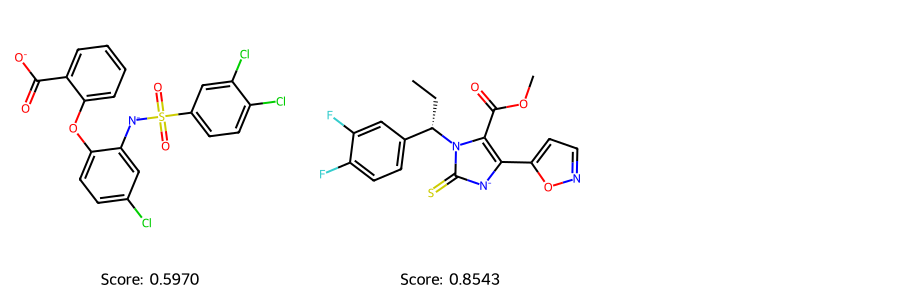

In [8]:
from rdkit import Chem
from rdkit.Chem import Draw

# Convert SMILES to RDKit molecules
mols = [Chem.MolFromSmiles(smi) for smi in test_smiles]

# Create labels with scores
legends = [f"Score: {score:.4f}" for score in scores]

# Display molecules with their scores
img = Draw.MolsToGridImage(mols, molsPerRow=3, legends=legends, subImgSize=(300, 300))
img

In [9]:
### 2.2 Smart CLI ROCS Integration

# Import Smart CLI ROCS Scorer
from drugex.training.scorers.smart_cli_rocs import SmartCLIROCSScorer

# Configure Smart CLI ROCS scorer
smart_cli_scorer = SmartCLIROCSScorer(
    query_files=sq_files,
    max_conformers=10,
    max_isomers=4,
    max_heavy_atoms=45,
    max_rotatable_bonds=15,
    shape_only=False,
    rocs_binary="rocs"
)

print("✅ Smart CLI ROCS Scorer configured successfully")


✅ Smart CLI ROCS Scorer configured successfully


In [ ]:
# Run Reinforcement Learning Training
print(f"Starting RL training - epochs={EPOCHS}, patience={PATIENCE}")

# Clear memory before intensive RL training
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

start_time = time.time()
log_memory("RL training start")

# Run reinforcement learning with Smart CLI ROCS
explorer.fit(monitor=monitor, epochs=EPOCHS, patience=PATIENCE)

end_time = time.time()
log_memory("RL training end")

training_time = end_time - start_time
print(f"RL training completed in {training_time/60:.1f} minutes")

# Load and display training progress
training_df = pd.read_csv(f"{MODEL_DIR_RL}/rocs_agent_fit.tsv", sep='\t')
print(f"Training summary: {len(training_df)} epochs recorded")
print(f"   Final desired ratio: {training_df['desired_ratio'].iloc[-1]:.3f}")
print(f"   Final loss: {training_df['loss_train'].iloc[-1]:.3f}")

# Get Smart CLI ROCS performance statistics
perf_stats = smart_cli_scorer.get_performance_stats()
print(f"\nSmart CLI ROCS Performance:")
for key, value in perf_stats.items():
    if isinstance(value, float):
        print(f"   {key}: {value:.3f}")
    else:
        print(f"   {key}: {value}")


Starting RL training - epochs=20, patience=5
RL training start: 35.2% used, 20.1GB available


Fitting SMILES RNN explorer:   0%|          | 0/20 [00:00<?, ?it/s]

Starting ROCS scoring for 100 molecules...
Conformer generation: 0 cached, 96 generated (hit rate: 0.0%)
  ROCS execution: 5.3s
  ROCS execution: 5.5s
  ROCS execution: 5.3s
  ROCS execution: 5.3s
ROCS scoring completed in 45.7s
Cache: 2.0% hit rate, 98 entries, 136.9MB


Calculating policy gradient...:   0%|          | 0/1 [00:00<?, ?it/s]

Starting ROCS scoring for 10 molecules...
Conformer generation: 0 cached, 10 generated (hit rate: 0.0%)
  ROCS execution: 2.2s
  ROCS execution: 2.2s
  ROCS execution: 2.1s
  ROCS execution: 2.1s
ROCS scoring completed in 12.0s
Cache: 1.8% hit rate, 108 entries, 151.1MB
Starting ROCS scoring for 100 molecules...


...

Conformer generation: 0 cached, 86 generated (hit rate: 0.0%)
  ROCS execution: 3.3s
  ROCS execution: 3.3s
  ROCS execution: 3.2s
  ROCS execution: 3.4s
ROCS scoring completed in 36.1s
Cache: 0.1% hit rate, 270 entries, 195.6MB


Calculating policy gradient...:   0%|          | 0/1 [00:00<?, ?it/s]

Starting ROCS scoring for 10 molecules...
Conformer generation: 0 cached, 9 generated (hit rate: 0.0%)
  ROCS execution: 2.0s
  ROCS execution: 2.0s
  ROCS execution: 2.1s
  ROCS execution: 2.1s
ROCS scoring completed in 10.4s
Cache: 0.1% hit rate, 279 entries, 203.8MB
Starting ROCS scoring for 100 molecules...
Conformer generation: 1 cached, 82 generated (hit rate: 1.2%)
  ROCS execution: 3.7s
  ROCS execution: 3.8s
  ROCS execution: 3.8s
  ROCS execution: 3.7s
ROCS scoring completed in 27.7s
Cache: 0.2% hit rate, 361 entries, 272.5MB


Calculating policy gradient...:   0%|          | 0/1 [00:00<?, ?it/s]

Starting ROCS scoring for 10 molecules...
Conformer generation: 0 cached, 9 generated (hit rate: 0.0%)
  ROCS execution: 2.0s
Error in single query scoring: ROCS execution failed: ROCS failed with return code -11
  ROCS execution: 2.0s
ROCS scoring completed in 9.1s
Cache: 0.2% hit rate, 370 entries, 278.2MB
RL training end: 39.9% used, 18.6GB available
RL training completed in 20.6 minutes
Training summary: 20 epochs recorded
   Final desired ratio: 0.900
   Final loss: 0.092

Smart CLI ROCS Performance:
   caching_enabled: True
   cache_stats: {'size_mb': 278.21998596191406, 'max_size_mb': 512, 'entries': 370, 'hit_rate': 0.0015267175572519084, 'hits': 3, 'misses': 1962, 'evictions': 1435, 'corrupted': False}
   memory_info: {'total_gb': 31.05071258544922, 'available_gb': 18.647178649902344, 'used_gb': 11.76470947265625, 'used_percent': 0.39899999999999997, 'free_gb': 10.803947448730469}
   config: {'max_conformers': 50, 'max_isomers': 4, 'batch_size_limit': 500, 'process_isolation_t

In [ ]:
# Run Reinforcement Learning Training
print(f"Starting RL training - epochs={EPOCHS}, patience={PATIENCE}")

# Clear memory before intensive RL training
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

start_time = time.time()
log_memory("RL training start")

# Run reinforcement learning with Smart CLI ROCS
explorer.fit(monitor=monitor, epochs=EPOCHS, patience=PATIENCE)

end_time = time.time()
log_memory("RL training end")

training_time = end_time - start_time
print(f"RL training completed in {training_time/60:.1f} minutes")

# Load and display training progress
training_df = pd.read_csv(f"{MODEL_DIR_RL}/rocs_agent_fit.tsv", sep='\t')
print(f"Training summary: {len(training_df)} epochs recorded")
print(f"   Final desired ratio: {training_df['desired_ratio'].iloc[-1]:.3f}")
print(f"   Final loss: {training_df['loss_train'].iloc[-1]:.3f}")

# Get Smart CLI ROCS performance statistics
perf_stats = smart_cli_scorer.get_performance_stats()
print(f"\nSmart CLI ROCS Performance:")
for key, value in perf_stats.items():
    if isinstance(value, float):
        print(f"   {key}: {value:.3f}")
    else:
        print(f"   {key}: {value}")


Starting RL training - epochs=20, patience=5
RL training start: 35.2% used, 20.1GB available


Fitting SMILES RNN explorer:   0%|          | 0/20 [00:00<?, ?it/s]

Starting ROCS scoring for 100 molecules...
Conformer generation: 0 cached, 96 generated (hit rate: 0.0%)
  ROCS execution: 5.3s
  ROCS execution: 5.5s
  ROCS execution: 5.3s
  ROCS execution: 5.3s
ROCS scoring completed in 45.7s
Cache: 2.0% hit rate, 98 entries, 136.9MB


Calculating policy gradient...:   0%|          | 0/1 [00:00<?, ?it/s]

Starting ROCS scoring for 10 molecules...
Conformer generation: 0 cached, 10 generated (hit rate: 0.0%)
  ROCS execution: 2.2s
  ROCS execution: 2.2s
  ROCS execution: 2.1s
  ROCS execution: 2.1s
ROCS scoring completed in 12.0s
Cache: 1.8% hit rate, 108 entries, 151.1MB
Starting ROCS scoring for 100 molecules...


...

Conformer generation: 0 cached, 86 generated (hit rate: 0.0%)
  ROCS execution: 3.3s
  ROCS execution: 3.3s
  ROCS execution: 3.2s
  ROCS execution: 3.4s
ROCS scoring completed in 36.1s
Cache: 0.1% hit rate, 270 entries, 195.6MB


Calculating policy gradient...:   0%|          | 0/1 [00:00<?, ?it/s]

Starting ROCS scoring for 10 molecules...
Conformer generation: 0 cached, 9 generated (hit rate: 0.0%)
  ROCS execution: 2.0s
  ROCS execution: 2.0s
  ROCS execution: 2.1s
  ROCS execution: 2.1s
ROCS scoring completed in 10.4s
Cache: 0.1% hit rate, 279 entries, 203.8MB
Starting ROCS scoring for 100 molecules...
Conformer generation: 1 cached, 82 generated (hit rate: 1.2%)
  ROCS execution: 3.7s
  ROCS execution: 3.8s
  ROCS execution: 3.8s
  ROCS execution: 3.7s
ROCS scoring completed in 27.7s
Cache: 0.2% hit rate, 361 entries, 272.5MB


Calculating policy gradient...:   0%|          | 0/1 [00:00<?, ?it/s]

Starting ROCS scoring for 10 molecules...
Conformer generation: 0 cached, 9 generated (hit rate: 0.0%)
  ROCS execution: 2.0s
Error in single query scoring: ROCS execution failed: ROCS failed with return code -11
  ROCS execution: 2.0s
ROCS scoring completed in 9.1s
Cache: 0.2% hit rate, 370 entries, 278.2MB
RL training end: 39.9% used, 18.6GB available
RL training completed in 20.6 minutes
Training summary: 20 epochs recorded
   Final desired ratio: 0.900
   Final loss: 0.092

Smart CLI ROCS Performance:
   caching_enabled: True
   cache_stats: {'size_mb': 278.21998596191406, 'max_size_mb': 512, 'entries': 370, 'hit_rate': 0.0015267175572519084, 'hits': 3, 'misses': 1962, 'evictions': 1435, 'corrupted': False}
   memory_info: {'total_gb': 31.05071258544922, 'available_gb': 18.647178649902344, 'used_gb': 11.76470947265625, 'used_percent': 0.39899999999999997, 'free_gb': 10.803947448730469}
   config: {'max_conformers': 50, 'max_isomers': 4, 'batch_size_limit': 500, 'process_isolation_t

## 2.3 Smart CLI ROCS OOM Testing

Testing the memory management fixes for the Smart CLI ROCS scorer


In [9]:
# Memory monitoring setup
import psutil
import time
import gc

def log_memory(stage):
    """Monitor memory usage at different stages"""
    mem = psutil.virtual_memory()
    print(f"{stage}: {mem.percent:.1f}% used, {mem.available/(1024**3):.1f}GB available")

# Test molecules - use existing data from notebook
test_molecules = [
    "O=C([O-])c1ccccc1Oc1ccc(Cl)cc1[N-]S(=O)(=O)c1ccc(Cl)c(Cl)c1",  
    "CC[C@@H](c1ccc(F)c(F)c1)n1c(C(=O)OC)c(-c2ccno2)[n-]c1=S",
    "CCc1ccc(NC(=O)c2ccc(S(=O)(=O)N3CCOCC3)cc2)cc1",
    "CC(C)N1CCN(c2ccc(C(=O)Nc3ccc(F)cc3)cc2)CC1",
    "CN1CCCC1c2cnc(NC(=O)c3ccc(S(=O)(=O)N4CCOCC4)cc3)s2"
] * 200  # Create 1000 mols

print(f"Created test set with {len(test_molecules)} molecules")
log_memory("Initial")


Created test set with 1000 molecules
Initial: 48.9% used, 15.9GB available


### OOM Test

Testing the original scenario that caused OOM (two scorers, large molecule set)


In [10]:
# Create two scorers
scorer1 = SmartCLIROCSScorer(sq_files[0], show_progress=True)
scorer2 = SmartCLIROCSScorer(sq_files[1], show_progress=True)

print("=== OOM Reproduction Test ===")
log_memory("Start")

# First scorer
print("\n--- First Scorer ---")
start = time.time()
scores1 = scorer1.getScores(test_molecules)
time1 = time.time() - start
log_memory("After scorer 1")
print(f"First scorer: {time1:.1f}s, {len(scores1)} scores")

# Second scorer  
print("\n--- Second Scorer ---")
start = time.time()
scores2 = scorer2.getScores(test_molecules)
time2 = time.time() - start
log_memory("After scorer 2")
print(f"Second scorer: {time2:.1f}s, {len(scores2)} scores")

print(f"\nTiming comparison: {time1:.1f}s → {time2:.1f}s")
print(f"✅ No OOM crash - test passed!")


=== OOM Reproduction Test ===
Start: 48.9% used, 15.9GB available

--- First Scorer ---
Starting ROCS scoring for 1000 molecules...
ROCS scoring completed in 136.9s
Cache: 0.0% hit rate, 0 entries, 0.0MB
After scorer 1: 49.4% used, 15.7GB available
First scorer: 136.9s, 1000 scores

--- Second Scorer ---
Starting ROCS scoring for 1000 molecules...
ROCS scoring completed in 139.2s
Cache: 0.0% hit rate, 0 entries, 0.0MB
After scorer 2: 48.9% used, 15.9GB available
Second scorer: 139.2s, 1000 scores

Timing comparison: 136.9s → 139.2s
✅ No OOM crash - test passed!


### Memory Stability Test

Testing multiple cycles to verify no memory accumulation


In [11]:
# Test multiple cycles for memory accumulation
print("=== Memory Stability Test ===")

small_test_mols = test_molecules[:100]

for cycle in range(3):
    print(f"\nCycle {cycle+1}")
    log_memory(f"Before cycle {cycle+1}")
    
    scorer = SmartCLIROCSScorer(sq_files[0])
    scores = scorer.getScores(small_test_mols)
    
    # Explicit cleanup
    scorer.cleanup_resources()
    del scorer
    gc.collect()
    
    log_memory(f"After cycle {cycle+1}")
    print(f"Cycle {cycle+1}: {len(scores)} scores generated")

print("\n✅ Memory stability test completed")


=== Memory Stability Test ===

Cycle 1
Before cycle 1: 48.9% used, 15.9GB available
After cycle 1: 49.1% used, 15.8GB available
Cycle 1: 100 scores generated

Cycle 2
Before cycle 2: 49.1% used, 15.8GB available
After cycle 2: 49.0% used, 15.8GB available
Cycle 2: 100 scores generated

Cycle 3
Before cycle 3: 49.0% used, 15.8GB available
After cycle 3: 49.2% used, 15.8GB available
Cycle 3: 100 scores generated

✅ Memory stability test completed


### Large Batch Test

Testing process isolation with very large molecule sets


In [12]:
# Test large batch (should trigger process isolation)
print("=== Large Batch Test ===")
large_mols = test_molecules * 2  # ~1850 molecules

log_memory("Before large batch")

scorer_large = SmartCLIROCSScorer(sq_files[0], show_progress=True)
start = time.time()
scores_large = scorer_large.getScores(large_mols)
elapsed = time.time() - start

log_memory("After large batch")

print(f"Processed {len(large_mols)} molecules in {elapsed:.1f}s")
print(f"Generated {len(scores_large)} scores")
print(f"Average: {elapsed/len(large_mols)*1000:.2f}ms per molecule")
print("✅ Large batch test completed")


=== Large Batch Test ===
Before large batch: 49.2% used, 15.8GB available
Starting ROCS scoring for 2000 molecules...
ROCS scoring completed in 274.1s
Cache: 95.0% hit rate, 0 entries, 0.0MB
After large batch: 50.9% used, 15.3GB available
Processed 2000 molecules in 274.1s
Generated 2000 scores
Average: 137.06ms per molecule
✅ Large batch test completed



Final check of OOM fix


In [13]:
# Final validation
final_mem = psutil.virtual_memory().percent
print(f"=== RESULTS ===")
print(f"Final memory usage: {final_mem:.1f}%")
print(f"Memory under control: {'✅' if final_mem < 85 else '❌'}")
print(f"Both scorers completed: {'✅' if len(scores1) > 0 and len(scores2) > 0 else '❌'}")
print(f"Large batch handled: {'✅' if len(scores_large) > 0 else '❌'}")

# Summary
if final_mem < 85 and len(scores1) > 0 and len(scores2) > 0 and len(scores_large) > 0:
    print("\n🎉 ALL TESTS PASSED!")
    print("✅ Smart CLI ROCS scorer is ready")
else:
    print("\n❌ Some tests failed - needs investigation")


=== RESULTS ===
Final memory usage: 50.9%
Memory under control: ✅
Both scorers completed: ✅
Large batch handled: ✅

🎉 ALL TESTS PASSED!
✅ Smart CLI ROCS scorer is ready


## 3. DrugEx Integration

Multi-objective optimization with:
- ROCS similarity (maximize)  
- Synthetic accessibility (minimize)


In [10]:
# Import additional required modules
from drugex.training.environment import DrugExEnvironment
from drugex.training.scorers.modifiers import SmoothClippedScore
from drugex.training.rewards import ParetoCrowdingDistance
from drugex.training.scorers.properties import Property
from drugex.data.corpus.vocabulary import VocSmiles
from drugex.training.generators import SequenceRNN
import gc
import torch

# Path to pretrained model (adjust as needed)
GPUS = [0]  # Use GPU 0
MODELS_PATH = "../data/models/pretrained/smiles-rnn/Papyrus05.5_smiles_rnn_PT"

if torch.cuda.is_available():
    torch.cuda.empty_cache()

voc = VocSmiles.fromFile(f'{MODELS_PATH}/Papyrus05.5_smiles_rnn_PT.vocab', encode_frags=False)

# Load pretrained model
pretrained = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
pretrained.loadStatesFromFile(f'{MODELS_PATH}/Papyrus05.5_smiles_rnn_PT.pkg')


/home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/drugex/training/interfaces.py:312: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.loadStates(torch.load(path, map_l

In [11]:
# Synthetic Accessibility Scorer (1-10 scale, lower = better)
sa_scorer = Property("SA")
sa_scorer.setModifier(SmoothClippedScore(lower_x=5, upper_x=3))  # Matches your graph

# ROCS Combo Scorer (0-2 scale, higher = better)
# rocs_scorer = Property("ROCS")
# rocs_scorer.setModifier(SmoothClippedScore(lower_x=0.5, upper_x=1.5))  # Prioritize scores 0.5-1.5

# Calculate normalized threshold for desired real ROCS ≥ 1.0
# Formula: (real_score - lower_x) / (upper_x - lower_x)
rocs_threshold = (1.0 - 0.5) / (1.5 - 0.5)  # = 0.5

# Thresholds in normalized scores (0-1)
thresholds = [
    0.35,    # ROCS: Real score ≥1.0 → normalized 0.5
    0.1     # SA: Real score ≤3.9 → normalized 0.3
]


In [12]:
# --------------------------
# Multi-Objective Optimization - Memory Optimized
# --------------------------

scorer_ez = [ez_rocs_scorer, sa_scorer]
scorer_fastrocs = [fastrocs_scorer, sa_scorer]  
scorer_smart_cli = [smart_cli_scorer, sa_scorer]  

print("✅ Scorers configured - Smart CLI ROCS recommended for RL to avoid OOM")


✅ Scorers configured - Smart CLI ROCS recommended for RL to avoid OOM


Available environments:
- **scorer_ez**: EZ ROCS + SA score 
- **scorer_fastrocs**: FastROCS + SA score (GPU optimized)
- **scorer_smart_cli**: Smart CLI ROCS + SA score (intelligent preprocessing)


In [13]:
# Memory optimization: Force cleanup of any existing scorers
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

env_smart = DrugExEnvironment(
    scorers=scorer_smart_cli,  
    thresholds=thresholds,
    reward_scheme=ParetoCrowdingDistance()
)

env_fastrocs = DrugExEnvironment(
    scorers=scorer_fastrocs,  
    thresholds=thresholds,
    reward_scheme=ParetoCrowdingDistance()
)

# Test Smart CLI ROCS environment
print("Testing Smart CLI ROCS in DrugEx environment...")
smart_test_scores = env_smart.getScores(test_smiles)
print(f"✅ Smart CLI Environment working: {len(smart_test_scores) > 0}")
print(f"✅ Using Smart CLI ROCS for RL training to prevent OOM")

Testing Smart CLI ROCS in DrugEx environment...
✅ Smart CLI Environment working: True
✅ Using Smart CLI ROCS for RL training to prevent OOM


## 4. DrugEx Training

In [14]:
from drugex.data.processing import CorpusEncoder, RandomTrainTestSplitter, Standardization
from drugex.training.explorers import SequenceExplorer
from drugex.training.monitors import FileMonitor
import multiprocessing as mp
from drugex.data.corpus.corpus import SequenceCorpus
from drugex.data.datasets import SmilesDataSet

CPU_COUNT = max(1, mp.cpu_count() - 4) 
MODEL_DIR_RL = "./rocs_rl_ccr"
if not os.path.exists(MODEL_DIR_RL):
    os.makedirs(MODEL_DIR_RL)

# Clear GPU memory before training
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"Fine-tuning device: {'GPU' if GPUS else 'CPU'} (GPUS: {GPUS})")
print(f"CPU cores used: {CPU_COUNT}/{mp.cpu_count()} (conservative for memory)")

voc = VocSmiles.fromFile(f'{MODELS_PATH}/Papyrus05.5_smiles_rnn_PT.vocab', encode_frags=False)
pretrained = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
pretrained.loadStatesFromFile(f'{MODELS_PATH}/Papyrus05.5_smiles_rnn_PT.pkg')
data_path = "CCR_HUMAN_AL.tsv"
print(f"Loading fine-tuning data from {data_path}")
df = pd.read_csv(data_path, sep='\t')



Fine-tuning device: GPU (GPUS: [0])
CPU cores used: 28/32 (conservative for memory)
Loading fine-tuning data from CCR_HUMAN_AL.tsv


/home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/drugex/training/interfaces.py:312: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.loadStates(torch.load(path, map_l

In [15]:
if 'SMILES' not in df.columns:
    print(f"ERROR: No 'SMILES' column found in {data_path}")

X_train = df['SMILES'].values
model = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
model.load_state_dict(pretrained.state_dict())

CHUNK_SIZE = 512  
BATCH_SIZE = 256 
FT_EPOCHS = 50    

print(f"Memory-optimized settings: chunk={CHUNK_SIZE}, batch={BATCH_SIZE}, epochs={FT_EPOCHS}")

standardizer = Standardization(n_proc=CPU_COUNT, chunk_size=CHUNK_SIZE)
valid_smiles = standardizer.apply(X_train)
print(f"Found {len(valid_smiles)} valid SMILES strings for training")

# Memory cleanup before data processing
gc.collect()

os.makedirs(MODEL_DIR_RL, exist_ok=True)
corpus_file = os.path.join(MODEL_DIR_RL, "corpus.tsv")
voc_file = os.path.join(MODEL_DIR_RL, "model.vocab")
encoder = CorpusEncoder(
    SequenceCorpus,
    {'vocabulary': voc, 'update_voc': False, 'throw': True},
    n_proc=CPU_COUNT,
    chunk_size=CHUNK_SIZE
)

Memory-optimized settings: chunk=512, batch=256, epochs=50


Standardizing molecules (batch processing):   0%|          | 0/1 [00:00<?, ?it/s]

Found 1021 valid SMILES strings for training


In [16]:
data_collector = SmilesDataSet(corpus_file, rewrite=True)
encoder.apply(valid_smiles, collector=data_collector)
voc.toFile(voc_file)

print(f"Saved vocabulary to {voc_file}")
splitter = RandomTrainTestSplitter(0.05, 1e4)
train, test = splitter(data_collector.getData())
for data, name in zip([train, test], ['train', 'test']):
    pd.DataFrame(data, columns=data_collector.getColumns()).to_csv(
        os.path.join(MODEL_DIR_RL, f'ligand_{name}.tsv'),
        header=True, index=False, sep='\t'
    )

SequenceCorpus (batch processing):   0%|          | 0/1 [00:00<?, ?it/s]

Molecule does not meet min/max words requirements (min: 10, max: 100). Words found: {'c', ')', 'F', '2', 'C', 'L', 'EOS', '3', '(', 'S', 'N', 'O', '=', '1'} (occurrence count: 102). It will be ignored.


Saved vocabulary to ./rocs_rl_ccr/model.vocab


In [17]:
import torch

def cleanup_gpu_memory():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

# Monkey patch the environment to cleanup after scoring
original_getScores = env_smart.getScores
def getScores_with_cleanup(*args, **kwargs):
    scores = original_getScores(*args, **kwargs)
    cleanup_gpu_memory()
    return scores
env_smart.getScores = getScores_with_cleanup

### 4.1 Fine-tuning

In [18]:
# data_set_train = SmilesDataSet(os.path.join(MODEL_DIR_RL, 'ligand_train.tsv'), voc=voc)
# train_loader = data_set_train.asDataLoader(batch_size=BATCH_SIZE)
# data_set_test = SmilesDataSet(os.path.join(MODEL_DIR_RL, 'ligand_test.tsv'), voc=voc)
# valid_loader = data_set_test.asDataLoader(batch_size=BATCH_SIZE)
# print(f"Fine-tuning model for {FT_EPOCHS} epochs")

# model.fit(train_loader, valid_loader, epochs=FT_EPOCHS,
#              monitor=FileMonitor(
#                  f"{MODEL_DIR_RL}/finetune", 
#                  save_smiles=True,
#                  reset_directory=True
#                  ))

# os.makedirs(MODEL_DIR_RL, exist_ok=True)
# model_path = f'{MODEL_DIR_RL}/finetune.pkg'
# voc.toFile(f'{MODEL_DIR_RL}/finetune.vocab')
# print(f"Model saved to {model_path}")
# print("Fine-tuning completed successfully")


### 4.2 Reinforcement Learning



In [19]:
try:
    vocab_path = f'{MODEL_DIR_RL}/finetune.vocab'
    voc = VocSmiles.fromFile(vocab_path, encode_frags=False)
except FileNotFoundError:
    print("Finetuned vocabulary not found, using pretrained vocabulary instead")
    voc = VocSmiles.fromFile(f'{MODELS_PATH}/Papyrus05.5_smiles_rnn_PT.vocab', encode_frags=False)

try:
    finetuned = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
    finetuned.loadStatesFromFile(f'{MODEL_DIR_RL}/finetune.pkg')
except FileNotFoundError:
    print("Finetuned model not found, using pretrained model instead")
    finetuned = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
    finetuned.loadStatesFromFile(f'{MODELS_PATH}/Papyrus05.5_smiles_rnn_PT.pkg')


Finetuned vocabulary not found, using pretrained vocabulary instead


/home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/drugex/training/interfaces.py:312: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.loadStates(torch.load(path, map_l

In [20]:
# Memory optimization: Clear GPU cache before RL training
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

# Memory-optimized explorer settings for OOM prevention
explorer = SequenceExplorer(
    agent=finetuned,
    env=env_smart, 
    mutate=pretrained,
    epsilon=0.1,
    batch_size=200,  
    n_samples=200,   
    use_gpus=GPUS
)

print(f"✅ RL Explorer configured with batch_size=200")

# Set up output directory for training logs
os.makedirs(MODEL_DIR_RL, exist_ok=True)

# Configure monitor to track progress
monitor = FileMonitor(
    f"{MODEL_DIR_RL}/rocs_agent", 
    save_smiles=True,          
    reset_directory=True     



Removing rocs_agent_fit.log from ./rocs_rl_ccr
Removing rocs_agent_fit.tsv from ./rocs_rl_ccr
Removing rocs_agent_smiles.tsv from ./rocs_rl_ccr
Removing rocs_agent.pkg from ./rocs_rl_ccr


✅ RL Explorer configured with batch_size=200 (memory-optimized)


### 4.3 Model Training


In [21]:
EPOCHS = 20
PATIENCE = 5

print(f"Starting RL training - epochs={EPOCHS}, patience={PATIENCE}")

# Clear memory before intensive RL training
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Run reinforcement learningDrugExEnvironment
explorer.fit(monitor=monitor, epochs=EPOCHS, patience=PATIENCE)

# Load training progress
training_df = pd.read_csv(f"{MODEL_DIR_RL}/rocs_agent_fit.tsv", sep='\t')
print(f"✅ RL training completed - {len(training_df)} epochs recorded")


Starting RL training - epochs=20, patience=5 (memory-optimized)


Fitting SMILES RNN explorer:   0%|          | 0/20 [00:00<?, ?it/s]

Calculating policy gradient...:   0%|          | 0/1 [00:00<?, ?it/s]

Calculating policy gradient...:   0%|          | 0/1 [00:00<?, ?it/s]

Calculating policy gradient...:   0%|          | 0/1 [00:00<?, ?it/s]

...

Calculating policy gradient...:   0%|          | 0/1 [00:00<?, ?it/s]

Calculating policy gradient...:   0%|          | 0/1 [00:00<?, ?it/s]

Calculating policy gradient...:   0%|          | 0/1 [00:00<?, ?it/s]

Calculating policy gradient...:   0%|          | 0/1 [00:00<?, ?it/s]

✅ RL training completed - 20 epochs recorded


In [22]:
training_df.head(20)

,Epoch,valid_ratio,unique_ratio,desired_ratio,avg_amean,avg_gmean,loss_train,best_epoch
0,1,0.95,0.90,0.85,0.705,0.650,0.260,1
1,2,0.85,0.85,0.80,0.711,0.661,0.052,1
2,3,0.75,0.75,0.75,0.735,0.706,0.040,1
3,4,0.85,0.85,0.80,0.699,0.653,0.054,1
4,5,0.90,0.90,0.70,0.632,0.539,0.043,1
5,6,0.90,0.90,0.90,0.719,0.684,0.054,6
6,7,0.85,0.85,0.75,0.703,0.665,0.061,6
7,8,0.85,0.85,0.85,0.690,0.657,0.058,6
8,9,0.90,0.90,0.90,0.717,0.678,0.065,6
9,10,0.95,0.95,0.85,0.729,0.687,0.061,6


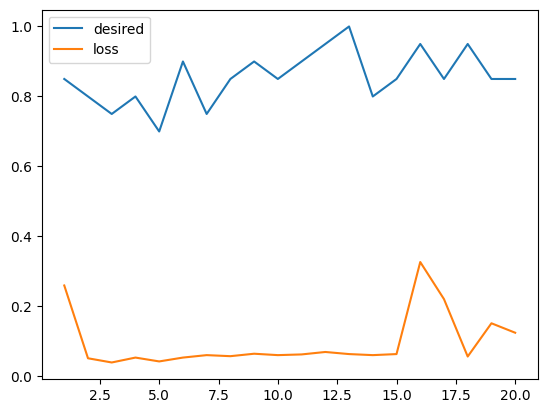

In [23]:
# linear plot of the training progress
plt.plot(training_df['Epoch'], training_df['desired_ratio'], label='desired')
plt.plot(training_df['Epoch'], training_df['loss_train'], label='loss')
plt.legend()
plt.show()


In [24]:
# Memory optimization: Clear cache before model loading
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Load the trained model
optimized_model = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
optimized_model.loadStatesFromFile(f"{MODEL_DIR_RL}/rocs_agent.pkg")

NUM_SAMPLES = 1000  

print(f"Generating {NUM_SAMPLES} molecules")
generated = optimized_model.generate(num_samples=NUM_SAMPLES)


Generating 1000 molecules


/home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/drugex/training/interfaces.py:312: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.loadStates(torch.load(path, map_l

Generating molecules:   0%|          | 0/1000 [00:00<?, ?it/s]

In [25]:
generated

,SMILES,Valid
0,Cc1cccc(-c2cnccc2-c2cnc(NCC(c3ccccc3)N3CCOCC3)...,1.0
1,CCOC(=O)N1CCC(NS(=O)(=O)c2ccc(OCc3ccoc3)cc2)C(...,1.0
2,CC(=O)C1=CC(c2ccccc2)C(=O)N1,1.0
3,Cc1ccccc1C(=O)c1ccccc1O,1.0
4,Cc1ccccc1C(=O)Nc1ccc(NS(=O)(=O)c2ccccc2)cc1,1.0
...,...,...
995,CC1CCN(C(=O)c2oc3ccccc3c2NS(=O)(=O)c2ccc(C(C)(...,1.0
996,O=C(c1ccccc1)c1ccc2oc3ccccc3c(=O)c2c1,1.0
997,Cc1ccccc1C(=O)NCCCNC(=O)c1cnccn1,1.0
998,COc1cccc2c1c(NS(=O)(=O)c1ccc(C)cc1)nn2Cc1cccc(...,1.0


=== DEBUGGING SCORES ===
Available columns: ['Valid', 'ROCS', 'SA', 'Desired']
DataFrame shape: (1000, 4)
DataFrame head:
   Valid   ROCS        SA  Desired
0    1.0  0.562  0.862097        1
1    1.0  0.486  0.670855        1
2    1.0  0.476  0.856285        1
3    1.0  0.467  0.992404        1
4    1.0  0.424  0.991393        1

Scorer keys in environment:
  - ROCS
  - SA

=== SUMMARY STATISTICS ===
Generated 1000 molecules
Desirable molecules: 966 (96.6%)
Average ROCS score: 0.5006
Average SA score: 0.9377


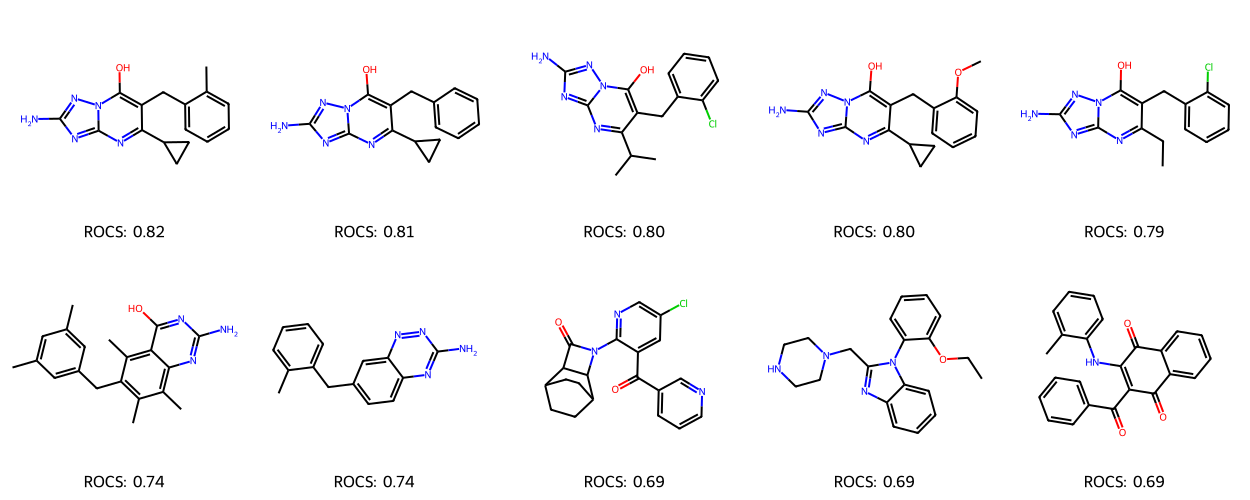

In [26]:
generated_smiles = generated.SMILES.tolist()

# Score the generated molecules
scores = env_smart.getScores(generated_smiles)
scores_df = pd.DataFrame(scores)

# DEBUG: Check what columns exist
print("=== DEBUGGING SCORES ===")
print(f"Available columns: {list(scores_df.columns)}")
print(f"DataFrame shape: {scores_df.shape}")
print(f"DataFrame head:")
print(scores_df.head())

# Check scorer keys
print(f"\nScorer keys in environment:")
for scorer in env_smart.scorers:
    print(f"  - {scorer.getKey()}")

# Display summary statistics
print(f"\n=== SUMMARY STATISTICS ===")
print(f"Generated {len(generated_smiles)} molecules")
print(f"Desirable molecules: {scores_df['Desired'].sum()} ({scores_df['Desired'].mean()*100:.1f}%)")
print(f"Average ROCS score: {scores_df['ROCS'].mean():.4f}")
print(f"Average SA score: {scores_df['SA'].mean():.4f}")

# Show top 10 molecules by ROCS score
top_by_rocs = scores_df.sort_values('ROCS', ascending=False).head(10)
top_indices = top_by_rocs.index.tolist()
top_smiles = [generated_smiles[i] for i in top_indices]
top_scores = top_by_rocs['ROCS'].tolist()

# Convert to RDKit molecules and display
top_mols = [Chem.MolFromSmiles(smi) for smi in top_smiles]
legends = [f"ROCS: {score:.2f}" for score in top_scores]
img = Draw.MolsToGridImage(top_mols, molsPerRow=5, legends=legends, subImgSize=(250, 250))
img